In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.seasonal import STL

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

cart_df    = pd.read_csv("metrics/cart-service.csv",    parse_dates=['timestamp'], index_col='timestamp')
order_df   = pd.read_csv("metrics/order-service.csv",   parse_dates=['timestamp'], index_col='timestamp')
payment_df = pd.read_csv("metrics/payment-service.csv", parse_dates=['timestamp'], index_col='timestamp')
gateway_df = pd.read_csv("metrics/api-gateway.csv",     parse_dates=['timestamp'], index_col='timestamp')

cart_df['memory_usage_mb']  = cart_df['memory_usage_bytes'] / (1024 * 1024)
cart_df['memory_limit_mb']  = cart_df['memory_limit_bytes'] / (1024 * 1024)
cart_df['memory_util_pct']  = cart_df['memory_usage_mb'] / cart_df['memory_limit_mb'] * 100
cart_df['restart_delta']    = cart_df['container_restart_count'].diff().fillna(0)
restart_timestamps          = cart_df[cart_df['restart_delta'] > 0].index

print(f"cart-service  : {len(cart_df)} rows")
print(f"order-service : {len(order_df)} rows")
print(f"payment-service: {len(payment_df)} rows")
print(f"api-gateway   : {len(gateway_df)} rows")
print(f"Restart events: {len(restart_timestamps)}")
for ts in restart_timestamps:
    print(f"  → {ts}  (mem before: {cart_df.loc[ts, 'memory_usage_mb']:.1f} MB)")


cart-service  : 2820 rows
order-service : 2820 rows
payment-service: 2820 rows
api-gateway   : 2820 rows
Restart events: 7
  → 2026-06-01 20:00:00+00:00  (mem before: 388.5 MB)
  → 2026-06-01 21:22:30+00:00  (mem before: 300.2 MB)
  → 2026-06-01 22:05:30+00:00  (mem before: 454.9 MB)
  → 2026-06-01 22:53:00+00:00  (mem before: 408.7 MB)
  → 2026-06-01 23:17:30+00:00  (mem before: 308.3 MB)
  → 2026-06-01 23:21:00+00:00  (mem before: 307.3 MB)
  → 2026-06-01 23:30:00+00:00  (mem before: 365.7 MB)


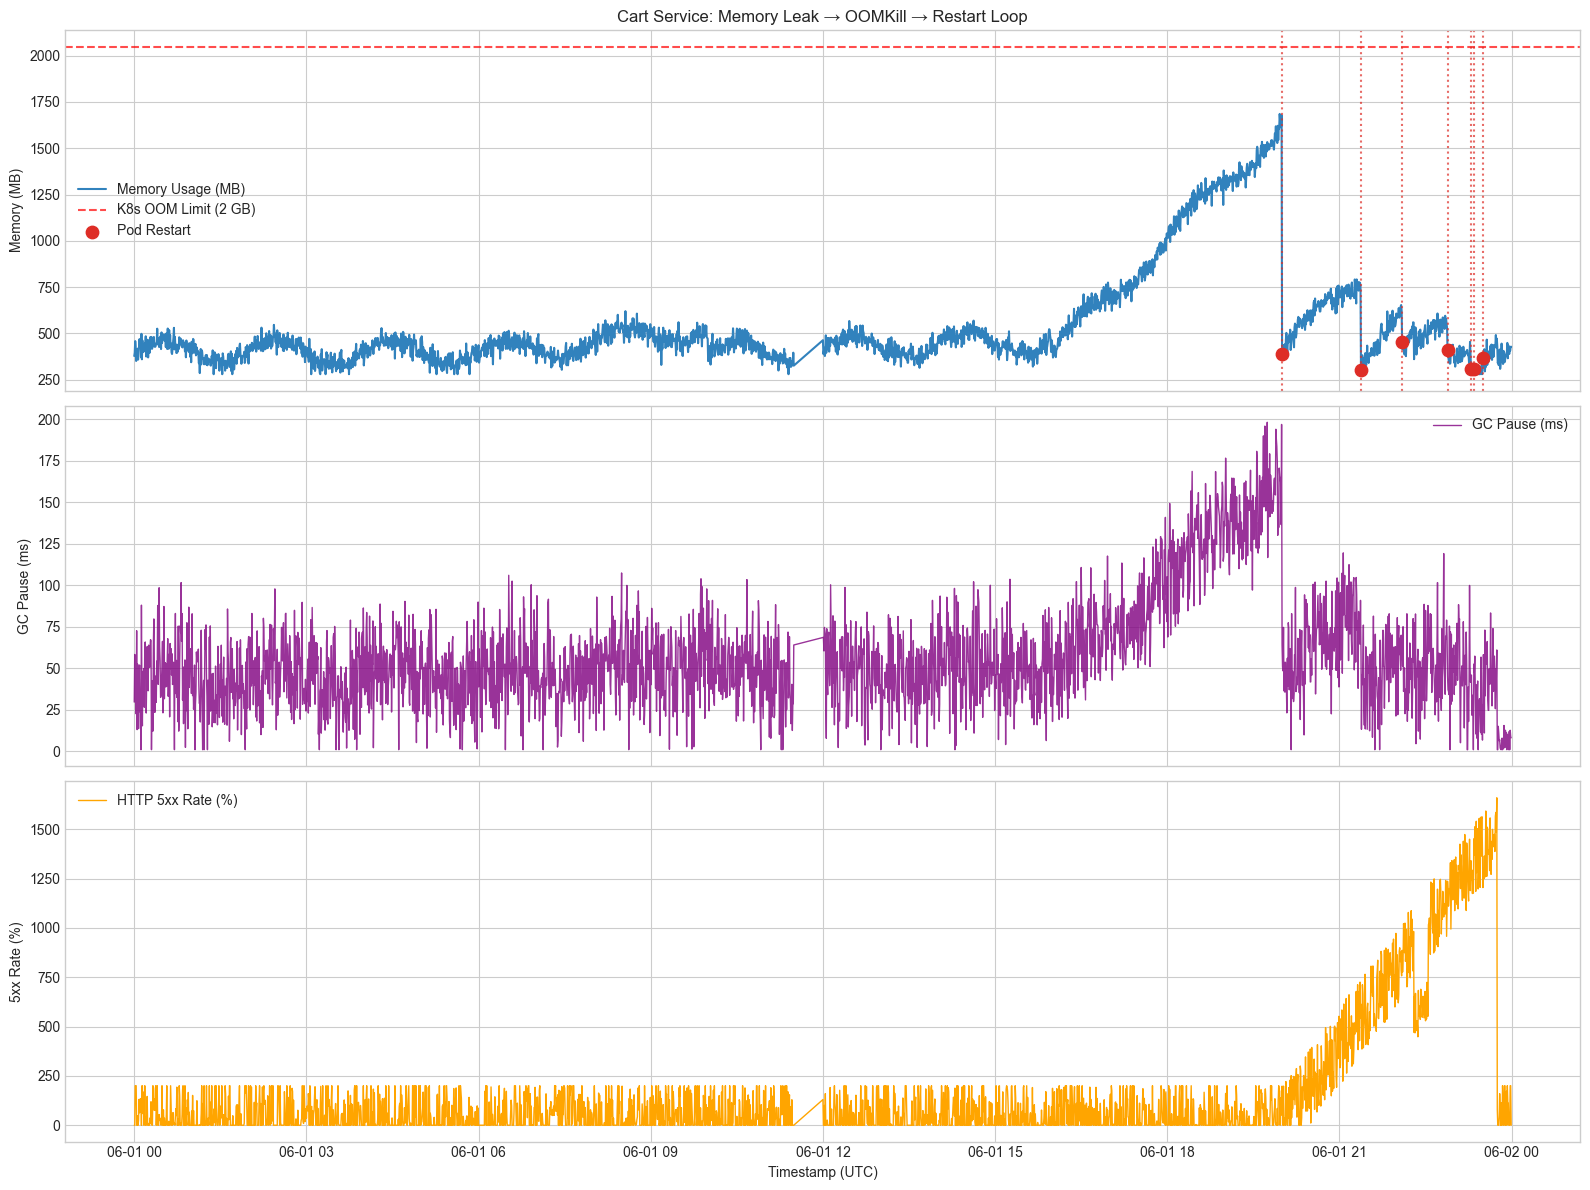

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(cart_df.index, cart_df['memory_usage_mb'], color='#3182bd', linewidth=1.5, label='Memory Usage (MB)')
axes[0].axhline(y=2048, color='red', linestyle='--', alpha=0.7, label='K8s OOM Limit (2 GB)')
for i, ts in enumerate(restart_timestamps):
    axes[0].axvline(x=ts, color='#de2d26', linestyle=':', alpha=0.7, linewidth=1.5)
    axes[0].scatter(ts, cart_df.loc[ts, 'memory_usage_mb'], color='#de2d26', s=80, zorder=5,
                    label='Pod Restart' if i == 0 else '')
axes[0].set_ylabel('Memory (MB)')
axes[0].set_title('Cart Service: Memory Leak → OOMKill → Restart Loop')
axes[0].legend()

axes[1].plot(cart_df.index, cart_df['jvm_gc_pause_ms_avg'], color='purple', linewidth=1, alpha=0.8, label='GC Pause (ms)')
axes[1].set_ylabel('GC Pause (ms)')
axes[1].legend()

axes[2].plot(cart_df.index, cart_df['http_5xx_rate'] * 100, color='orange', linewidth=1, label='HTTP 5xx Rate (%)')
axes[2].set_ylabel('5xx Rate (%)')
axes[2].set_xlabel('Timestamp (UTC)')
axes[2].legend()

plt.tight_layout()
plt.show()


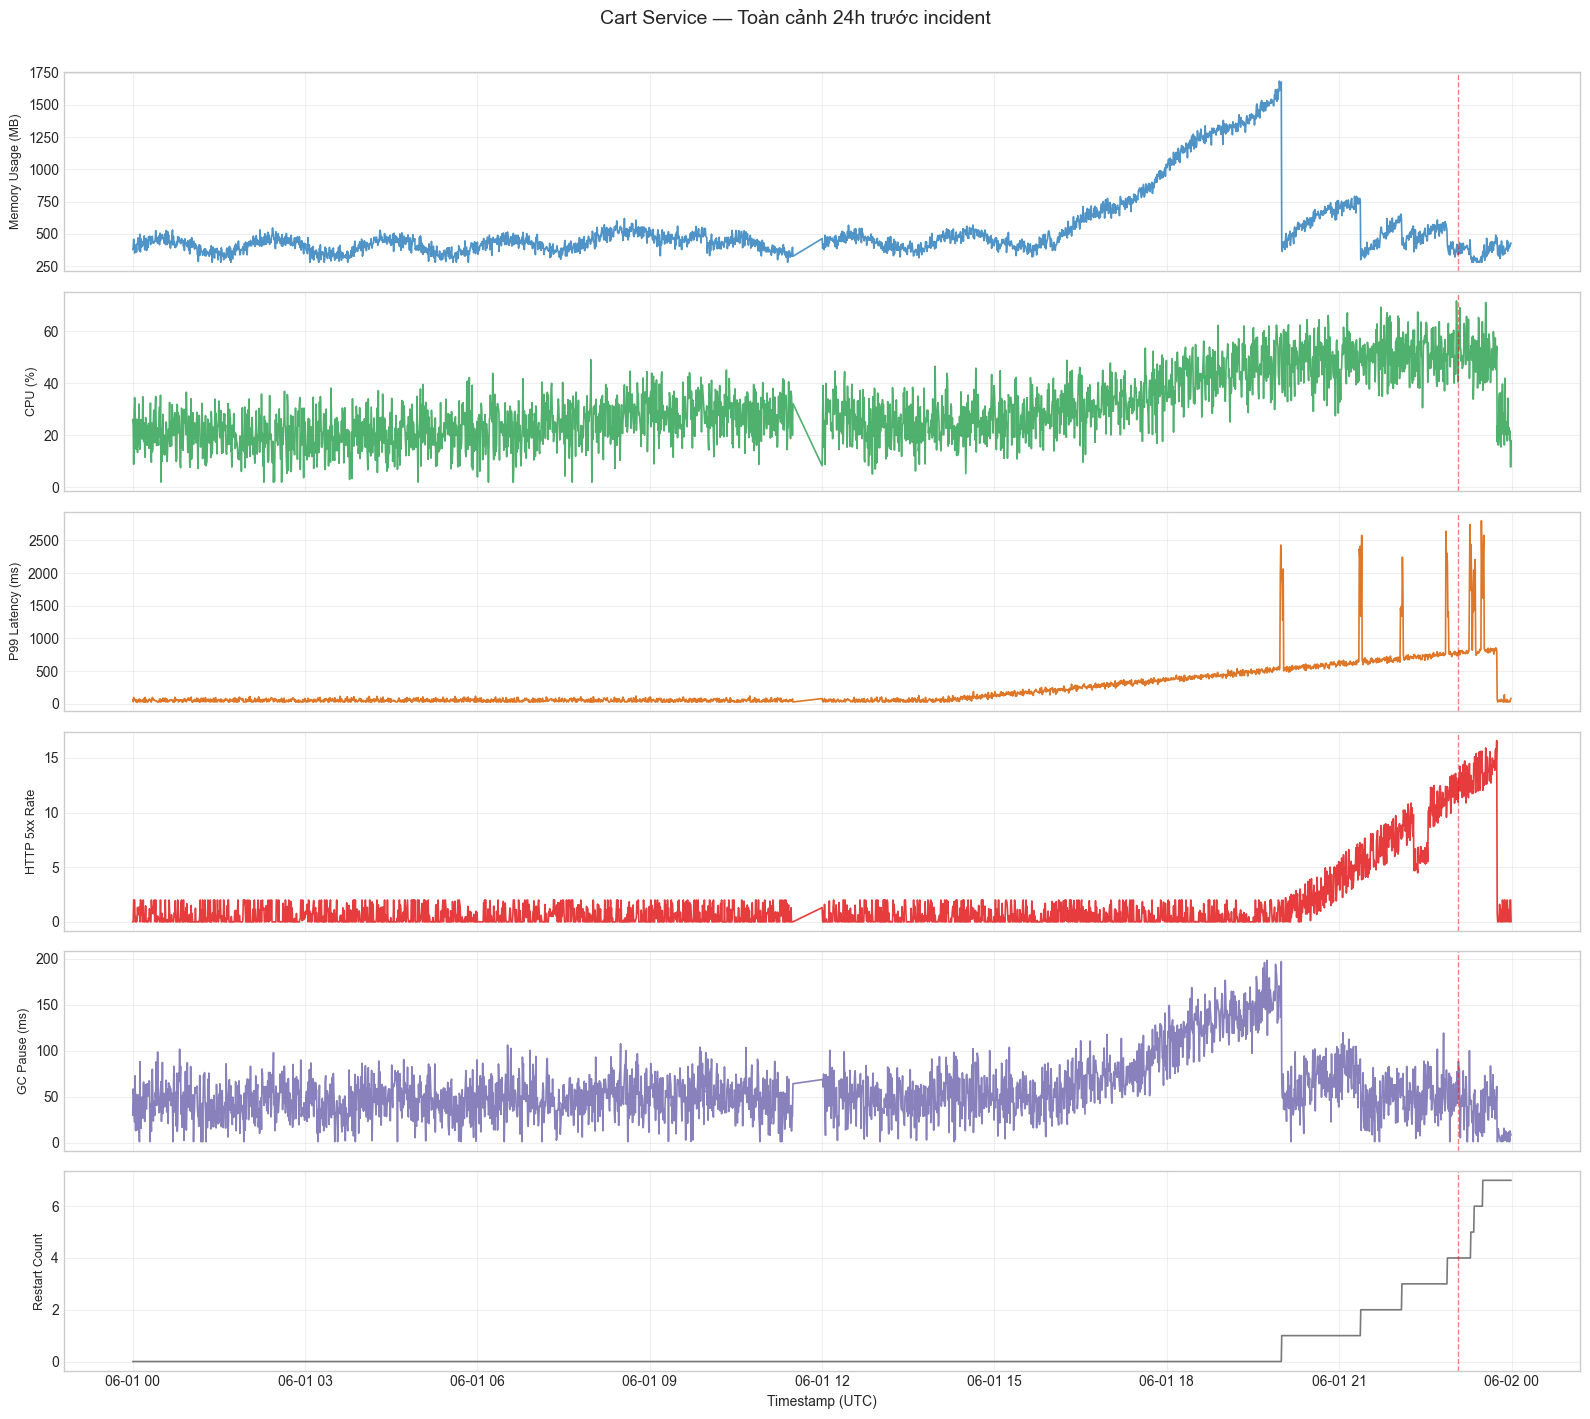

In [4]:
# ── OVERVIEW: Toàn bộ metrics cart-service theo timeline ──────────────────
cols = {
    'memory_usage_mb'       : ('Memory Usage (MB)',    '#3182bd'),
    'cpu_usage_percent'     : ('CPU (%)',               '#31a354'),
    'http_p99_latency_ms'   : ('P99 Latency (ms)',     '#d95f02'),
    'http_5xx_rate'         : ('HTTP 5xx Rate',         '#e31a1c'),
    'jvm_gc_pause_ms_avg'   : ('GC Pause (ms)',         '#756bb1'),
    'container_restart_count': ('Restart Count',        '#636363'),
}

fig, axes = plt.subplots(len(cols), 1, figsize=(16, 14), sharex=True)
fig.suptitle('Cart Service — Toàn cảnh 24h trước incident', fontsize=14, y=1.01)

for ax, (col, (label, color)) in zip(axes, cols.items()):
    ax.plot(cart_df.index, cart_df[col], color=color, linewidth=1.2, alpha=0.85)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

# Đánh dấu thời điểm alert (23:04)
alert_time = pd.Timestamp('2026-06-01 23:04:00')
for ax in axes:
    ax.axvline(x=alert_time, color='red', linestyle='--', alpha=0.5, linewidth=1)

axes[-1].set_xlabel('Timestamp (UTC)')
plt.tight_layout()
plt.show()


Phát hiện 141 điểm bất thường
Signal đầu tiên : 2026-06-01 18:02:30+00:00
Signal cuối cùng: 2026-06-01 23:48:30+00:00


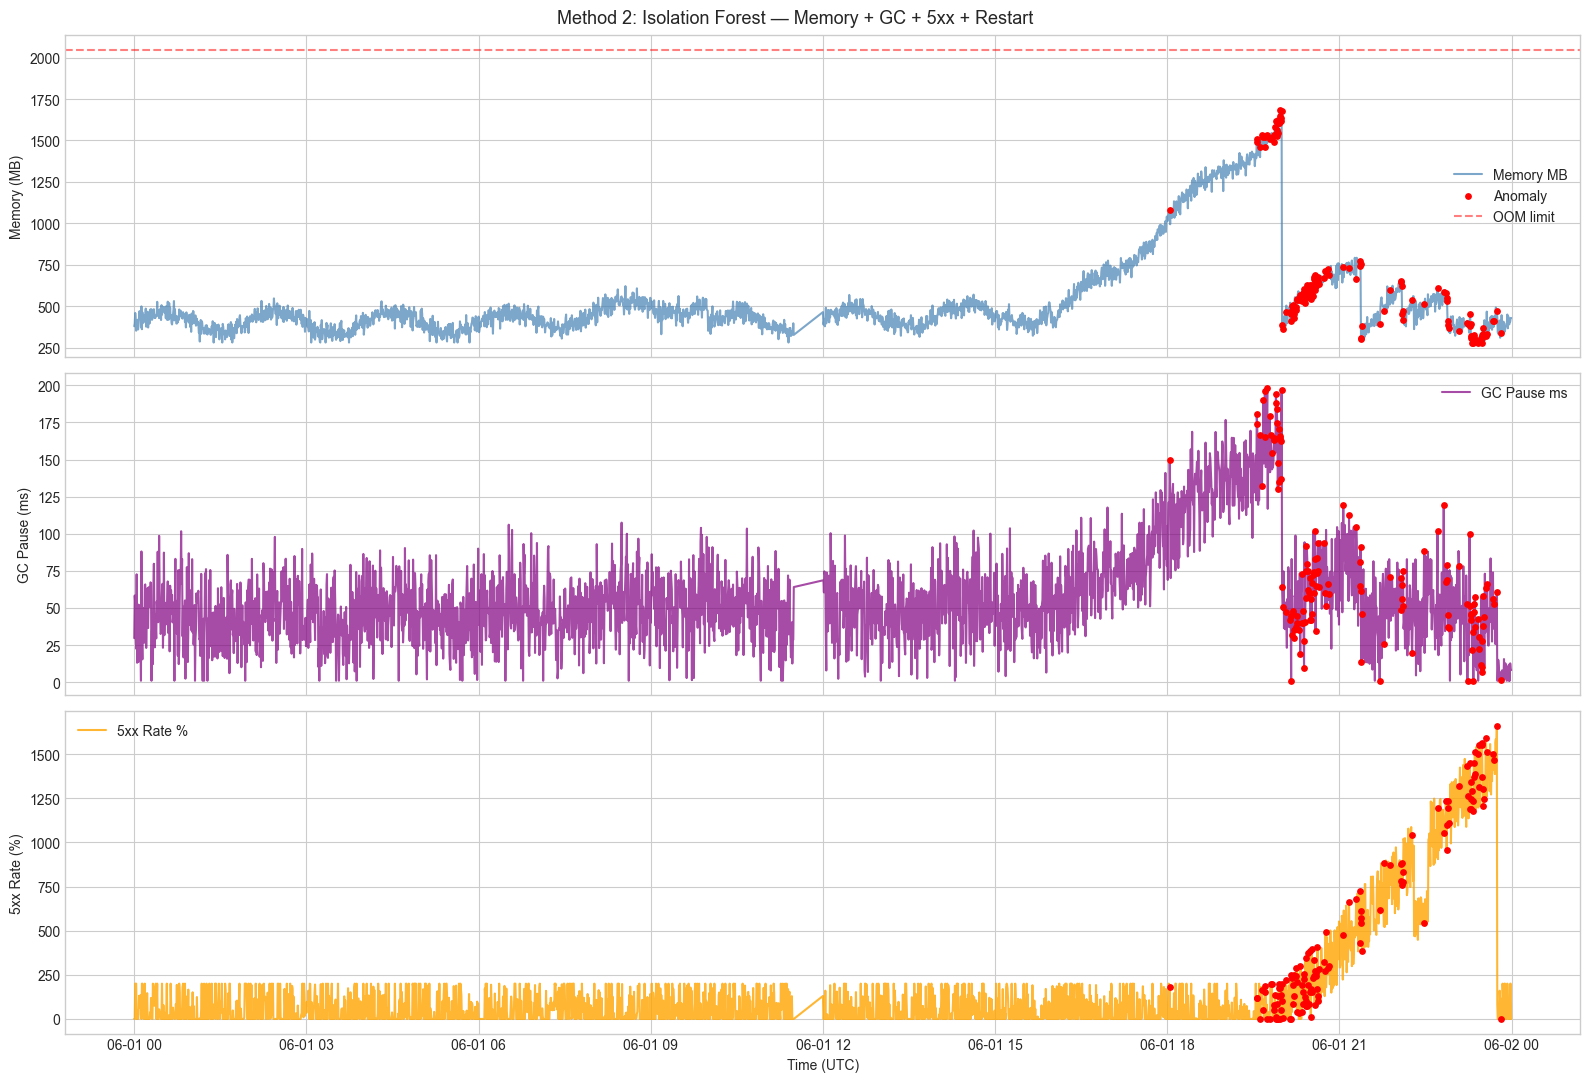

In [5]:
cart_ml = pd.read_csv("metrics/cart-service.csv", parse_dates=['timestamp'], index_col='timestamp')
cart_ml['memory_usage_mb'] = cart_ml['memory_usage_bytes'] / (1024 * 1024)
cart_ml['restart_delta']   = cart_ml['container_restart_count'].diff().fillna(0)

cart_ml['latency_residual'] = STL(cart_ml['http_p99_latency_ms'], period=120, robust=True).fit().resid
cart_ml['gc_residual']      = STL(cart_ml['jvm_gc_pause_ms_avg'],  period=120, robust=True).fit().resid
cart_ml['mem_slope_1h']     = cart_ml['memory_usage_mb'].rolling(120).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
)

features = [
    'latency_residual', 'gc_residual',
    'memory_usage_mb', 'mem_slope_1h',
    'http_5xx_rate', 'restart_delta',
    'cpu_usage_percent',
]
X = cart_ml[features].bfill().ffill()

iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
cart_ml['anomaly'] = np.where(iso.fit_predict(X) == -1, 1, 0)

anom = cart_ml[cart_ml['anomaly'] == 1]
print(f"Phát hiện {len(anom)} điểm bất thường")
print(f"Signal đầu tiên : {anom.index[0]}")
print(f"Signal cuối cùng: {anom.index[-1]}")

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].plot(cart_ml.index, cart_ml['memory_usage_mb'], color='steelblue', alpha=0.7, label='Memory MB')
axes[0].scatter(anom.index, anom['memory_usage_mb'], color='red', s=15, zorder=5, label='Anomaly')
axes[0].axhline(2048, color='red', linestyle='--', alpha=0.5, label='OOM limit')
axes[0].set_ylabel('Memory (MB)'); axes[0].legend()

axes[1].plot(cart_ml.index, cart_ml['jvm_gc_pause_ms_avg'], color='purple', alpha=0.7, label='GC Pause ms')
axes[1].scatter(anom.index, anom['jvm_gc_pause_ms_avg'], color='red', s=15, zorder=5)
axes[1].set_ylabel('GC Pause (ms)'); axes[1].legend()

axes[2].plot(cart_ml.index, cart_ml['http_5xx_rate'] * 100, color='orange', alpha=0.8, label='5xx Rate %')
axes[2].scatter(anom.index, anom['http_5xx_rate'] * 100, color='red', s=15, zorder=5)
axes[2].set_ylabel('5xx Rate (%)'); axes[2].set_xlabel('Time (UTC)'); axes[2].legend()

plt.suptitle('Method 2: Isolation Forest — Memory + GC + 5xx + Restart', fontsize=13)
plt.tight_layout()
plt.show()


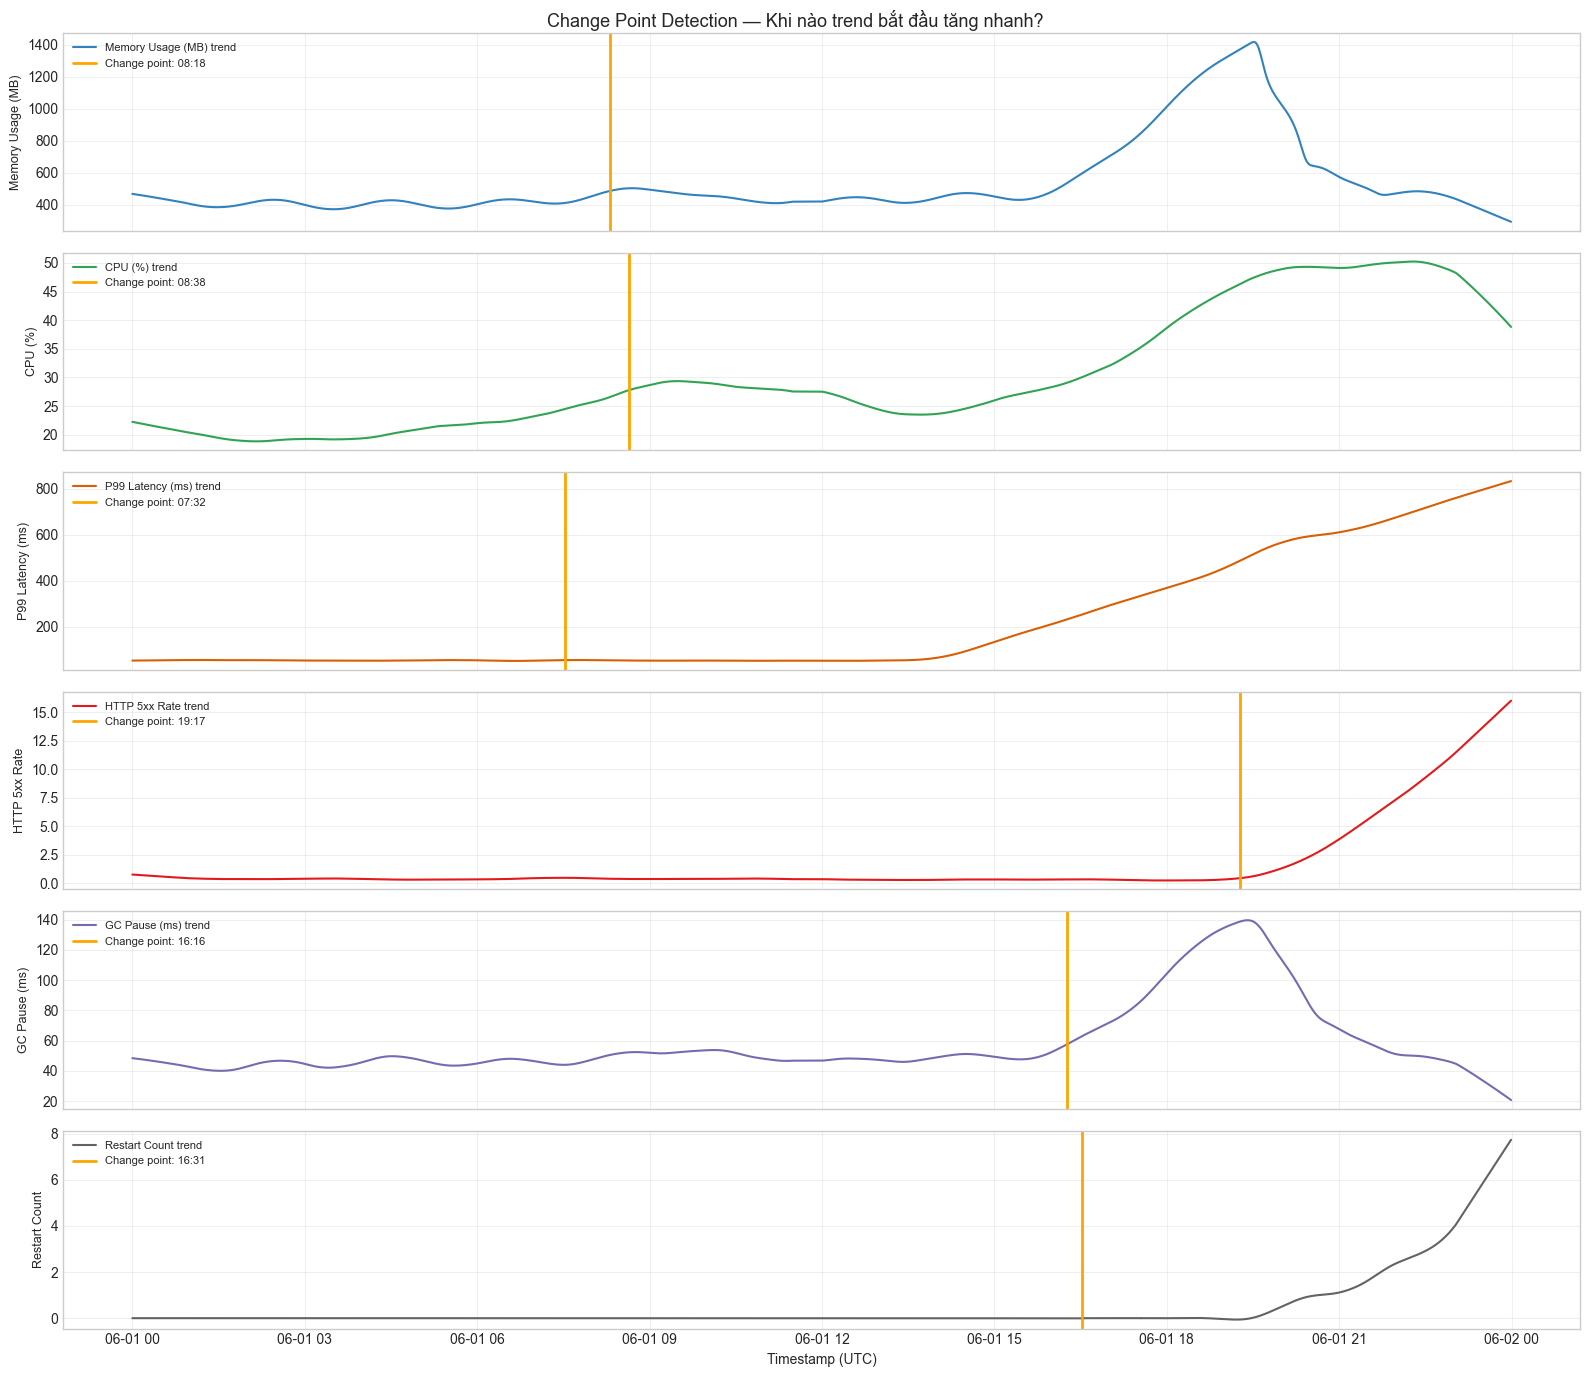


=== Change Point: Khi nào trend BẮT ĐẦU TĂNG NHANH ===
  [07:32] P99 Latency (ms)
  [08:18] Memory Usage (MB)
  [08:38] CPU (%)
  [16:16] GC Pause (ms)
  [16:31] Restart Count
  [19:17] HTTP 5xx Rate


In [6]:
# Định nghĩa các cột cần kiểm tra cùng tên hiển thị và màu sắc
cols = {
    'memory_usage_mb'       : ('Memory Usage (MB)',    '#3182bd'),
    'cpu_usage_percent'     : ('CPU (%)',               '#31a354'),
    'http_p99_latency_ms'   : ('P99 Latency (ms)',     '#d95f02'),
    'http_5xx_rate'         : ('HTTP 5xx Rate',         '#e31a1c'),
    'jvm_gc_pause_ms_avg'   : ('GC Pause (ms)',         '#756bb1'),
    'container_restart_count': ('Restart Count',        '#636363'),
}
# Tìm điểm trend THAY ĐỔI ĐỘT NGỘT, không phải điểm vượt ngưỡng
# Dùng diff của trend để phát hiện "khi nào bắt đầu tăng nhanh hơn bình thường"
fig, axes = plt.subplots(len(cols), 1, figsize=(16, 14), sharex=True)
fig.suptitle('Change Point Detection — Khi nào trend bắt đầu tăng nhanh?', fontsize=13)
results_cp = {}
for ax, (col, (label, color)) in zip(axes, cols.items()):
    # Lọc trend bằng STL (Giữ nguyên period=120 ~ 1 tiếng là rất tốt)
    trend = STL(cart_df[col].ffill(), period=120, robust=True).fit().trend
    trend_s = pd.Series(trend, index=cart_df.index)
    # Tối ưu: Giảm cửa sổ rolling xuống 120 sample (~1 tiếng) để tăng độ nhạy bén
    slope = trend_s.rolling(120).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
    )
    # Sửa lỗi: Baseline CHỈ lấy khoảng thời gian bình thường thực sự (trước 08:00)
    baseline_slope = slope['2026-06-01 01:00':'2026-06-01 08:00']
    
    # Giữ nguyên công thức threshold và kiểm tra liên tục 10 samples (5 phút)
    # Cộng thêm 1 số cực nhỏ (1e-6) để tránh lỗi khi đường trend nằm ngang hoàn toàn (std = 0)
    slope_threshold = baseline_slope.mean() + 2.0 * baseline_slope.std() + 1e-6
    # Tìm điểm slope vượt ngưỡng liên tục 10 sample
    above = slope > slope_threshold
    first_cp = None
    for i in range(len(above) - 10):
        if above.iloc[i:i+10].all():
            first_cp = above.index[i]
            break
            
    results_cp[label] = first_cp
    # Vẽ biểu đồ sử dụng màu từ dictionary
    ax.plot(trend_s.index, trend_s, linewidth=1.5, color=color, label=f'{label} trend')
    if first_cp:
        ax.axvline(x=first_cp, color='orange', linewidth=2,
                   label=f'Change point: {first_cp.strftime("%H:%M")}')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Timestamp (UTC)')
plt.tight_layout()
plt.show()
print("\n=== Change Point: Khi nào trend BẮT ĐẦU TĂNG NHANH ===")
for label, ts in sorted(results_cp.items(), key=lambda x: x[1] or pd.Timestamp.max):
    print(f"  [{ts.strftime('%H:%M') if ts else 'N/A'}] {label}")

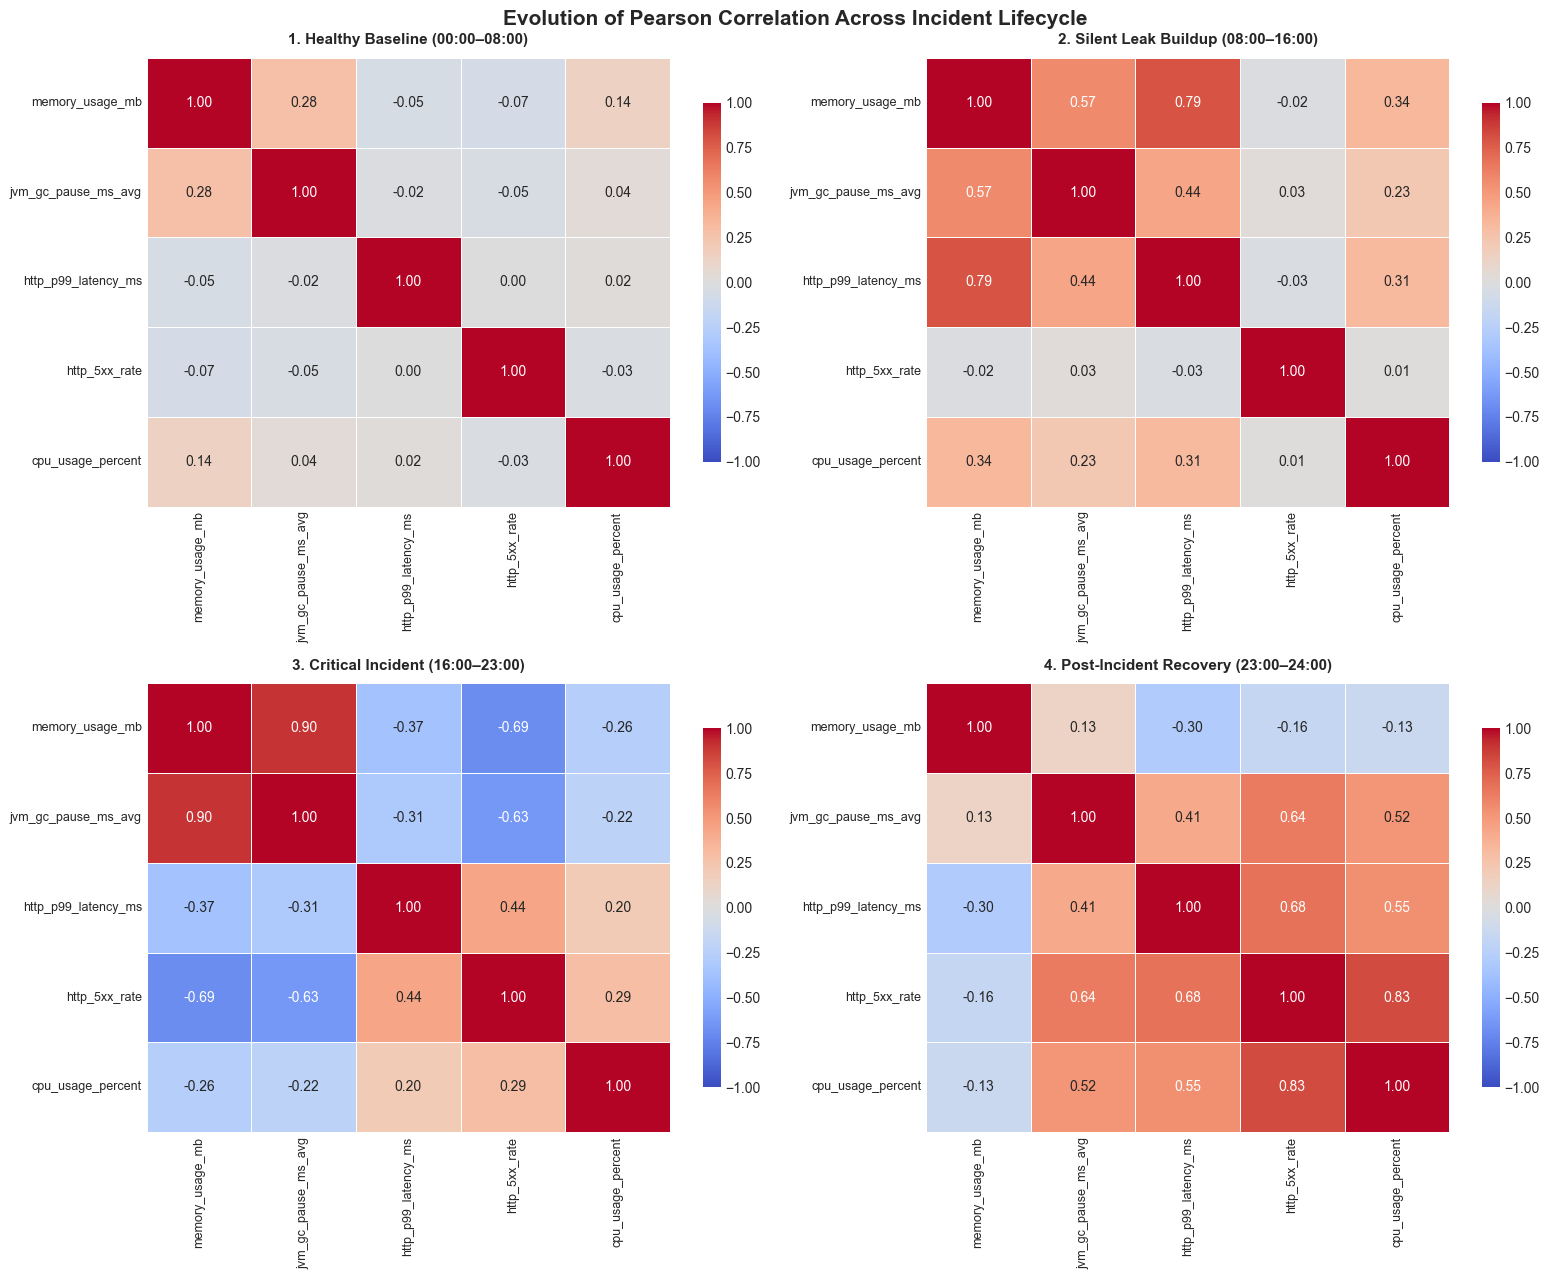

In [7]:
corr_cols = ['memory_usage_mb', 'jvm_gc_pause_ms_avg', 'http_p99_latency_ms', 'http_5xx_rate', 'cpu_usage_percent']

# Định nghĩa 4 giai đoạn dựa trên bằng chứng khoa học của STL và Isolation Forest
phases = {
    '1. Healthy Baseline (00:00–08:00)':       cart_df[:'2026-06-01 09:00:00'],
    '2. Silent Leak Buildup (08:00–16:00)':    cart_df['2026-06-01 09:00:00':'2026-06-01 18:00:00'],
    '3. Critical Incident (16:00–23:00)':      cart_df['2026-06-01 18:00:00':'2026-06-01 23:00:00'],
    '4. Post-Incident Recovery (23:00–24:00)': cart_df['2026-06-01 23:00:00':]
}

# Sử dụng lưới 2x2 để hiển thị trọn vẹn 4 phase
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()  # Phẳng hóa mảng để duyệt loop dễ dàng

for ax, (title, df) in zip(axes, phases.items()):
    if not df.empty and len(df) > 1:
        corr_matrix = df[corr_cols].corr()
        
        # Vẽ heatmap, ẩn phần tam giác trên (mask) nếu muốn sạch hơn, hoặc giữ nguyên toàn bộ
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
                    ax=ax, vmin=-1, vmax=1, linewidths=0.5,
                    cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.suptitle('Evolution of Pearson Correlation Across Incident Lifecycle', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

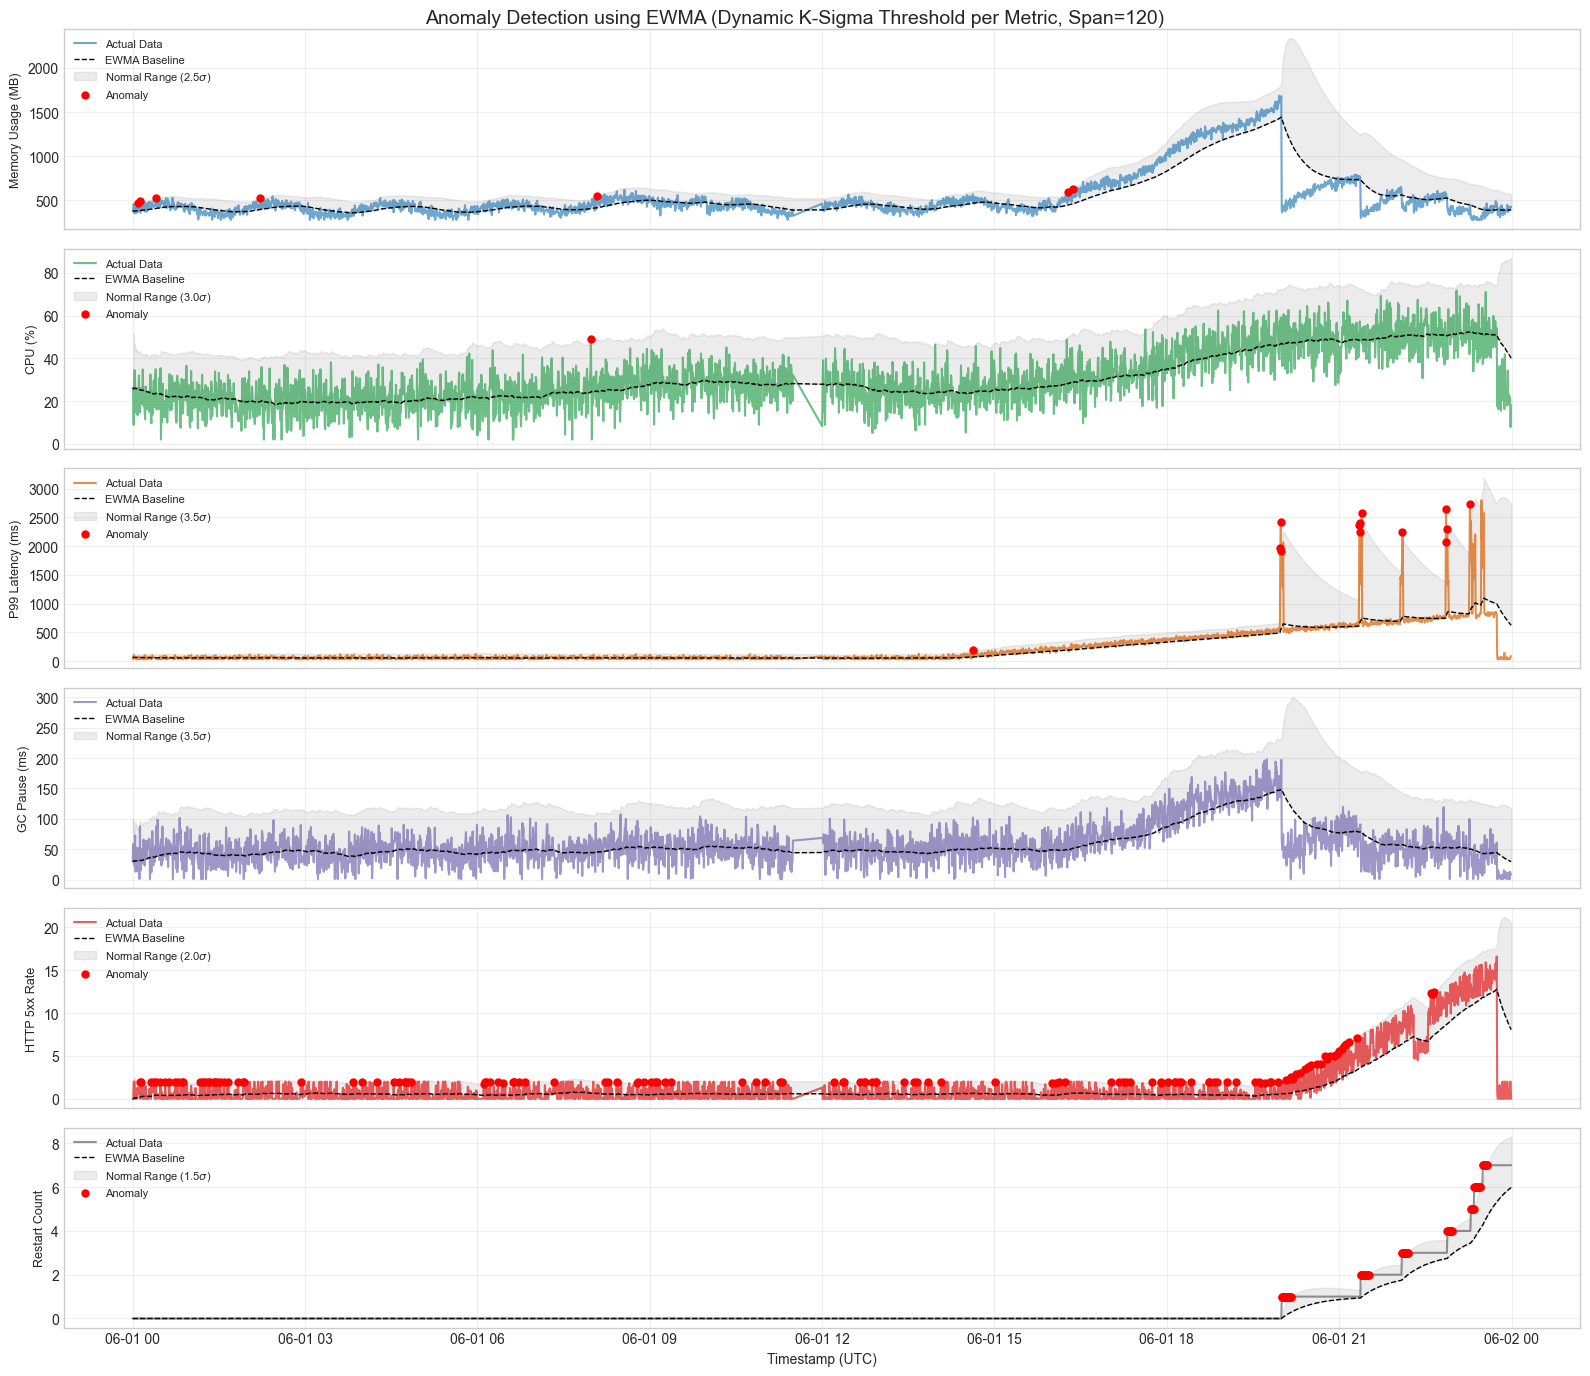


=== Điểm bắt đầu Anomaly (EWMA Dynamic K-Sigma) ===
  [00:05] Memory Usage (MB)  (Value: 469.6)
  [07:58] CPU (%)            (Value: 49.1)
  [14:38] P99 Latency (ms)   (Value: 187.4)
  [N/A]   GC Pause (ms)      No anomalies detected
  [00:08] HTTP 5xx Rate      (Value: 2.0)
  [20:00] Restart Count      (Value: 1.0)


In [8]:
SPAN = 120 # Cửa sổ thời gian vẫn giữ mức cao để bắt các trend chậm
cols = {
    'memory_usage_mb':        ('Memory Usage (MB)',    '#3182bd', 2.5), # Nhạy vừa phải để bắt trend leak sớm
    'cpu_usage_percent':      ('CPU (%)',               '#31a354', 3.0), # Kháng nhiễu gai CPU
    'http_p99_latency_ms':    ('P99 Latency (ms)',     '#d95f02', 3.5), # Kháng nhiễu cực mạnh cho độ trễ
    'jvm_gc_pause_ms_avg':    ('GC Pause (ms)',         '#756bb1', 3.5), # Kháng nhiễu cho GC giật cục
    'http_5xx_rate':          ('HTTP 5xx Rate',         '#e31a1c', 2.0), # Rất nhạy, có lỗi 5xx là phải bắt
    'container_restart_count':('Restart Count',        '#636363', 1.5), # Cực kỳ nhạy
}
fig, axes = plt.subplots(len(cols), 1, figsize=(16, 14), sharex=True)
fig.suptitle(f'Anomaly Detection using EWMA (Dynamic K-Sigma Threshold per Metric, Span={SPAN})', fontsize=14)
results_ewma = {}
# Phân tách cấu hình thành 3 biến: label, color, k_sigma
for ax, (col, (label, color, k_sigma)) in zip(axes, cols.items()):
    series = cart_df[col].ffill()
    
    # 1. Tính Trung bình trượt (EWMA Baseline) và Độ lệch chuẩn trượt (EWM_STD)
    ewma = series.ewm(span=SPAN, adjust=False).mean()
    ewm_std = series.ewm(span=SPAN, adjust=False).std()
    
    # Điền giá trị cho EWM_STD ở các điểm đầu tiên (tránh NaN)
    ewm_std = ewm_std.bfill().fillna(0)
    
    # 2. Tính ngưỡng cảnh báo trên (Upper Bound) dựa trên k_sigma riêng của TỪNG METRIC
    # Vẫn cộng thêm 0.01 vào std để chống nhiễu bắt nhầm khi dữ liệu bằng 0 quá lâu
    upper_bound = ewma + (k_sigma * np.maximum(ewm_std, 0.01))
    
    # 3. Phát hiện điểm dị thường (Actual Value > Upper Bound)
    anomalies = series[series > upper_bound]
    results_ewma[label] = anomalies
    
    # 4. Vẽ đồ thị
    ax.plot(series.index, series, label='Actual Data', color=color, alpha=0.7, linewidth=1.5)
    ax.plot(ewma.index, ewma, label='EWMA Baseline', color='black', linestyle='--', linewidth=1)
    
    # Cập nhật legend dải băng màu xám hiển thị số k_sigma đang dùng
    ax.fill_between(series.index, ewma, upper_bound, color='gray', alpha=0.15, label=f'Normal Range ({k_sigma}$\sigma$)')
    
    if not anomalies.empty:
        ax.scatter(anomalies.index, anomalies.values, color='red', marker='o', s=25, label='Anomaly', zorder=5)
        
    ax.set_ylabel(label, fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Timestamp (UTC)')
plt.tight_layout()
plt.show()
# 5. In kết quả thời điểm phát hiện bất thường đầu tiên
print("\n=== Điểm bắt đầu Anomaly (EWMA Dynamic K-Sigma) ===")
for label, anomalies in results_ewma.items():
    if not anomalies.empty:
        first_ano = anomalies.index[0]
        print(f"  [{first_ano.strftime('%H:%M')}] {label:<18} (Value: {anomalies.iloc[0]:.1f})")
    else:
        print(f"  [N/A]   {label:<18} No anomalies detected")

Phát hiện 18 điểm bất thường trong giai đoạn trước 15:00
Tín hiệu cảnh báo sớm (Early Signal) đầu tiên: 2026-06-01 02:02:30+00:00
Tín hiệu cuối cùng trong khung giờ này      : 2026-06-01 14:38:00+00:00


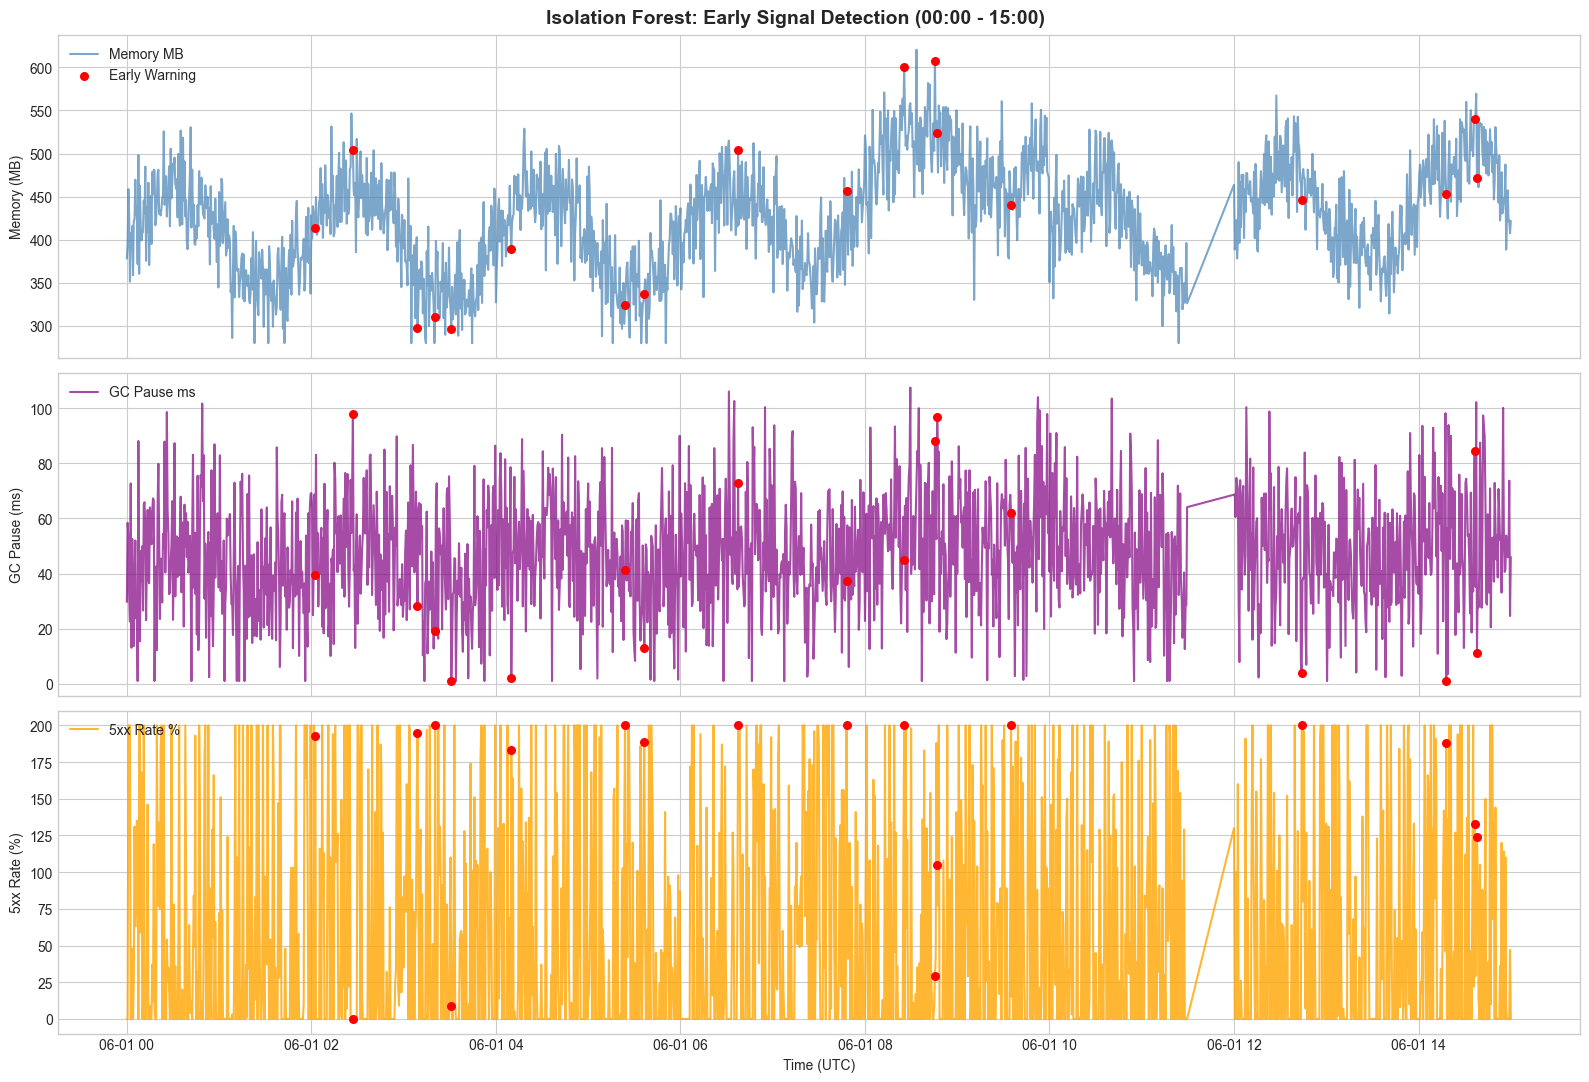

In [9]:
# 1. Đọc dữ liệu và tính toán base metrics
cart_ml = pd.read_csv("metrics/cart-service.csv", parse_dates=['timestamp'], index_col='timestamp')
cart_ml['memory_usage_mb'] = cart_ml['memory_usage_bytes'] / (1024 * 1024)
cart_ml['restart_delta']   = cart_ml['container_restart_count'].diff().fillna(0)
# 2. Trích xuất Features (Lọc qua STL và tính dốc)
cart_ml['latency_residual'] = STL(cart_ml['http_p99_latency_ms'], period=120, robust=True).fit().resid
cart_ml['gc_residual']      = STL(cart_ml['jvm_gc_pause_ms_avg'],  period=120, robust=True).fit().resid
cart_ml['mem_slope_1h']     = cart_ml['memory_usage_mb'].rolling(120).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
)
features = [
    'latency_residual', 'gc_residual', 'memory_usage_mb', 
    'mem_slope_1h', 'http_5xx_rate', 'restart_delta', 'cpu_usage_percent'
]
# 3. Focus vào giai đoạn trước 15:00 để tìm Early Signal
early_cart_ml = cart_ml.loc[:'2026-06-01 15:00:00'].copy()
X_early = early_cart_ml[features].bfill().ffill()
# Khởi tạo và chạy Isolation Forest CHỈ trên tập Early Data
# contamination=0.03 vì ta tin rằng chỉ có một tỷ lệ rất nhỏ điểm dữ liệu bắt đầu bị lỗi
iso = IsolationForest(contamination=0.01, n_estimators=200, random_state=42)
early_cart_ml['anomaly'] = np.where(iso.fit_predict(X_early) == -1, 1, 0)
anom = early_cart_ml[early_cart_ml['anomaly'] == 1]
# 4. Thống kê kết quả
print(f"Phát hiện {len(anom)} điểm bất thường trong giai đoạn trước 15:00")
if not anom.empty:
    print(f"Tín hiệu cảnh báo sớm (Early Signal) đầu tiên: {anom.index[0]}")
    print(f"Tín hiệu cuối cùng trong khung giờ này      : {anom.index[-1]}")
# 5. Trực quan hóa
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
# 5.1 Plot Memory
axes[0].plot(early_cart_ml.index, early_cart_ml['memory_usage_mb'], color='steelblue', alpha=0.7, label='Memory MB')
axes[0].scatter(anom.index, anom['memory_usage_mb'], color='red', s=30, zorder=5, label='Early Warning')
axes[0].set_ylabel('Memory (MB)')
axes[0].legend(loc='upper left')
# 5.2 Plot GC Pause
axes[1].plot(early_cart_ml.index, early_cart_ml['jvm_gc_pause_ms_avg'], color='purple', alpha=0.7, label='GC Pause ms')
axes[1].scatter(anom.index, anom['jvm_gc_pause_ms_avg'], color='red', s=30, zorder=5)
axes[1].set_ylabel('GC Pause (ms)')
axes[1].legend(loc='upper left')
# 5.3 Plot 5xx Rate
axes[2].plot(early_cart_ml.index, early_cart_ml['http_5xx_rate'] * 100, color='orange', alpha=0.8, label='5xx Rate %')
axes[2].scatter(anom.index, anom['http_5xx_rate'] * 100, color='red', s=30, zorder=5)
axes[2].set_ylabel('5xx Rate (%)')
axes[2].set_xlabel('Time (UTC)')
axes[2].legend(loc='upper left')
plt.suptitle('Isolation Forest: Early Signal Detection (00:00 - 15:00)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

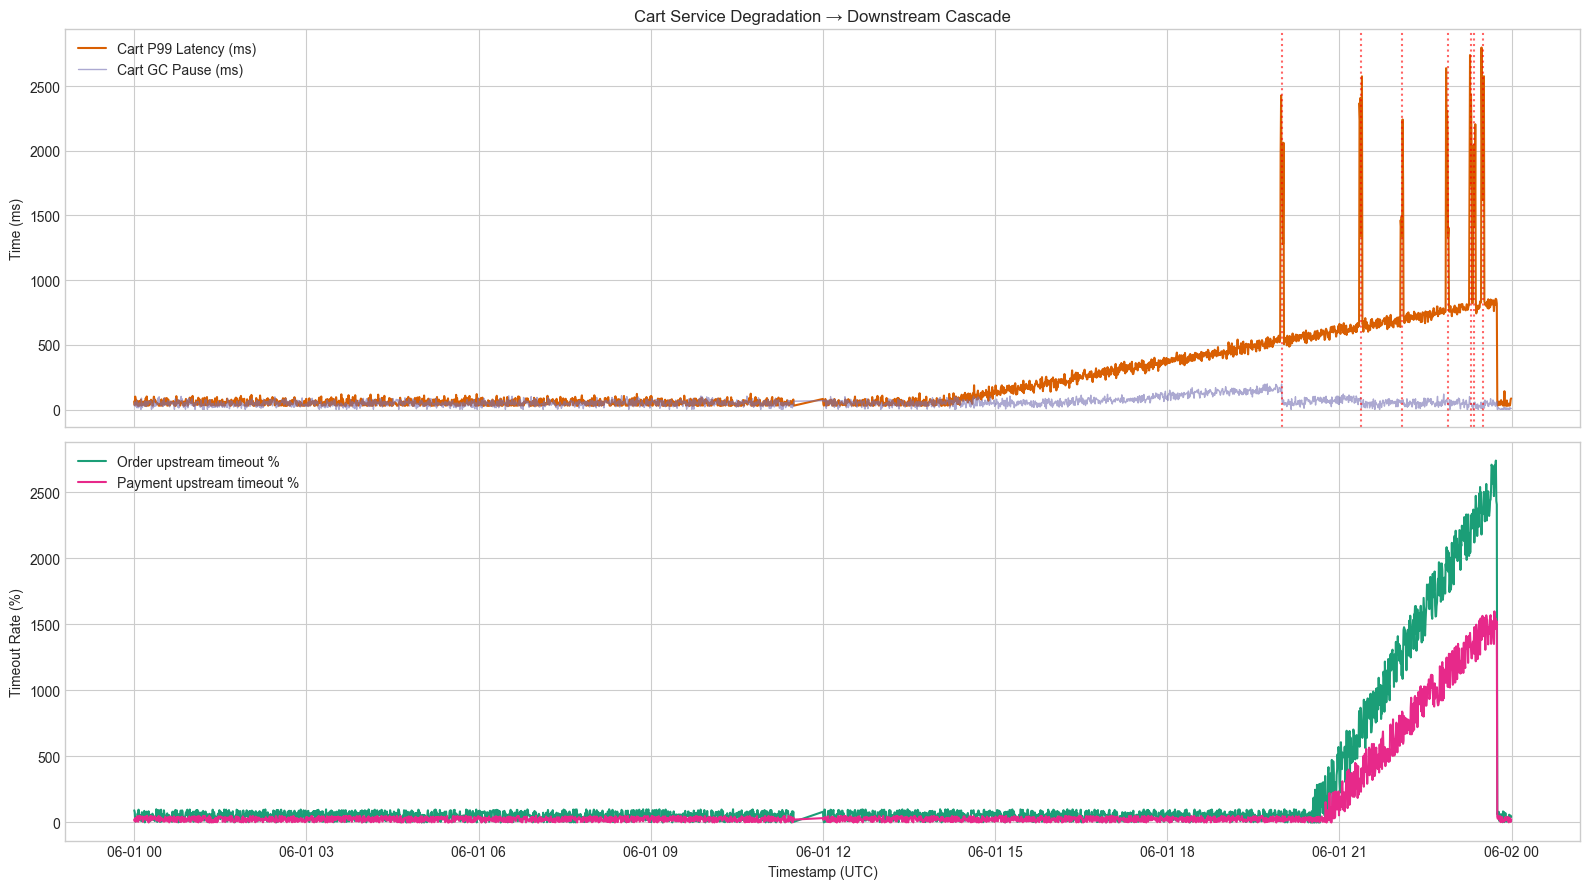

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax1.plot(cart_df.index, cart_df['http_p99_latency_ms'], color='#d95f02', linewidth=1.5, label='Cart P99 Latency (ms)')
ax1.plot(cart_df.index, cart_df['jvm_gc_pause_ms_avg'], color='#7570b3', linewidth=1, alpha=0.6, label='Cart GC Pause (ms)')
for ts in restart_timestamps:
    ax1.axvline(x=ts, color='red', linestyle=':', alpha=0.6)
ax1.set_ylabel('Time (ms)')
ax1.set_title('Cart Service Degradation → Downstream Cascade')
ax1.legend(loc='upper left')

ax2.plot(order_df.index,   order_df['upstream_timeout_rate'] * 100,   color='#1b9e77', linewidth=1.5, label='Order upstream timeout %')
ax2.plot(payment_df.index, payment_df['upstream_timeout_rate'] * 100, color='#e7298a', linewidth=1.5, label='Payment upstream timeout %')
ax2.set_ylabel('Timeout Rate (%)')
ax2.set_xlabel('Timestamp (UTC)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()
